<a href="https://colab.research.google.com/github/Suryanshsaraf/atml/blob/main/ATML_MiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Clone your ATML repository into Colab
!git clone https://github.com/Suryanshsaraf/atml.git

# 2. Change directory to the repo folder
%cd atml

# 3. Verify all downloaded datasets
!ls -lh data/

Cloning into 'atml'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 10 (delta 0), reused 10 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), 30.71 MiB | 17.50 MiB/s, done.
/content/atml
total 86M
-rw-r--r-- 1 root root  31M Sep  6 11:02 chicago_beach_weather_automated_sensors.csv
-rw-r--r-- 1 root root  42M Sep  6 11:02 jena_climate_2009_2016.csv
-rw-r--r-- 1 root root  13M Sep  6 11:02 jena_climate_2009_2016.csv.zip
-rw-r--r-- 1 root root 228K Sep  6 11:02 nab_ambient_temperature_system_failure.csv


In [2]:
# Cell 1: Setup & Data Ingestion
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, roc_auc_score, roc_curve, precision_recall_curve

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")
print(f"TensorFlow Version: {tf.__version__}")

# Load Jena Weather Station Dataset
jena_url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
print("\nDownloading and loading Jena Climate Dataset...")
df_raw = pd.read_csv(jena_url)

print(f"Dataset Loaded Successfully! Shape: {df_raw.shape}")
df_raw.head()

Libraries imported successfully!
TensorFlow Version: 2.20.0

Dataset Loaded Successfully! Shape: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [3]:
# Cell 2: Feature Engineering & Preprocessing
df = df_raw.copy()

# 1. Parse Date Time and set as Index
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df = df.sort_values('Date Time').reset_index(drop=True)

# 2. Select Core Weather Sensors
core_features = {
    'T (degC)': 'Temperature',
    'p (mbar)': 'Pressure',
    'rh (%)': 'Humidity',
    'Tdew (degC)': 'DewPoint',
    'wv (m/s)': 'WindSpeed'
}
df_selected = df[['Date Time'] + list(core_features.keys())].rename(columns=core_features)

# 3. Add Feature Engineering: Physical & Temporal Correlations
# A. Dew Point Spread (Physical Constraint: T - Tdew >= 0)
df_selected['DewPoint_Spread'] = df_selected['Temperature'] - df_selected['DewPoint']

# B. Rate of Change (Delta per 10-min interval)
df_selected['Temp_Delta'] = df_selected['Temperature'].diff().fillna(0)
df_selected['Pressure_Delta'] = df_selected['Pressure'].diff().fillna(0)

# C. Cyclical Hour of Day Encodings
hours = df_selected['Date Time'].dt.hour + df_selected['Date Time'].dt.minute / 60.0
df_selected['Hour_Sin'] = np.sin(2 * np.pi * hours / 24.0)
df_selected['Hour_Cos'] = np.cos(2 * np.pi * hours / 24.0)

# Clean any residual NaN values
df_selected = df_selected.dropna().reset_index(drop=True)

feature_cols = ['Temperature', 'Pressure', 'Humidity', 'DewPoint', 'WindSpeed',
                'DewPoint_Spread', 'Temp_Delta', 'Pressure_Delta', 'Hour_Sin', 'Hour_Cos']

print(f"Engineered Features ({len(feature_cols)}):", feature_cols)
df_selected.head()

Engineered Features (10): ['Temperature', 'Pressure', 'Humidity', 'DewPoint', 'WindSpeed', 'DewPoint_Spread', 'Temp_Delta', 'Pressure_Delta', 'Hour_Sin', 'Hour_Cos']


,Date Time,Temperature,Pressure,Humidity,DewPoint,WindSpeed,DewPoint_Spread,Temp_Delta,Pressure_Delta,Hour_Sin,Hour_Cos
0,2009-01-01 00:10:00,-8.02,996.52,93.3,-8.90,1.03,0.88,0.00,0.00,0.043619,0.999048
1,2009-01-01 00:20:00,-8.41,996.57,93.4,-9.28,0.72,0.87,-0.39,0.05,0.087156,0.996195
2,2009-01-01 00:30:00,-8.51,996.53,93.9,-9.31,0.19,0.80,-0.10,-0.04,0.130526,0.991445
3,2009-01-01 00:40:00,-8.31,996.51,94.2,-9.07,0.34,0.76,0.20,-0.02,0.173648,0.984808
4,2009-01-01 00:50:00,-8.27,996.51,94.1,-9.04,0.32,0.77,0.04,0.00,0.216440,0.976296


In [4]:
# Cell 3: Chronological Train/Test Split
split_idx = int(len(df_selected) * 0.80)

train_df = df_selected.iloc[:split_idx].copy()
test_df = df_selected.iloc[split_idx:].copy()

print(f"Total Rows: {len(df_selected)}")
print(f"Clean Training Set (2009–2014): {len(train_df)} rows")
print(f"Test Set (2015–2016):           {len(test_df)} rows")

Total Rows: 420551
Clean Training Set (2009–2014): 336440 rows
Test Set (2015–2016):           84111 rows


In [7]:
def inject_aws_anomalies(df_test, anomaly_rate=0.05):
    test_data = df_test.copy().reset_index(drop=True)
    n_rows = len(test_data)
    n_anomalies = int(n_rows * anomaly_rate)

    # Ground Truth Label: 0 = Normal, 1 = Anomaly
    labels = np.zeros(n_rows, dtype=int)

    # Randomly select indices for anomaly injection
    anomaly_indices = np.random.choice(n_rows - 50, size=n_anomalies, replace=False)

    # Divide anomaly indices among 5 realistic AWS fault types
    chunk = n_anomalies // 5
    spike_idx = anomaly_indices[0:chunk]
    stuck_idx = anomaly_indices[chunk:2*chunk]
    drift_idx = anomaly_indices[2*chunk:3*chunk]
    bound_idx = anomaly_indices[3*chunk:4*chunk]
    physics_idx = anomaly_indices[4*chunk:]

    # Fault 1: Sudden Temperature Spike / Drop (+15°C)
    for idx in spike_idx:
        test_data.loc[idx, 'Temperature'] += np.random.choice([15.0, -15.0])
        labels[idx] = 1

    # Fault 2: Stuck Sensor (Relative Humidity constant for 12 timesteps / 2 hours)
    for idx in stuck_idx:
        stuck_val = test_data.loc[idx, 'Humidity']
        for offset in range(12):
            if idx + offset < n_rows:
                test_data.loc[idx + offset, 'Humidity'] = stuck_val
                labels[idx + offset] = 1

    # Fault 3: Gradual Pressure Calibration Drift (-0.2 mbar per step for 18 steps)
    for idx in drift_idx:
        for offset in range(18):
            if idx + offset < n_rows:
                test_data.loc[idx + offset, 'Pressure'] -= 0.2 * (offset + 1)
                labels[idx + offset] = 1

    # Fault 4: Out-of-Bounds Sensor Output (Humidity = 145%)
    for idx in bound_idx:
        test_data.loc[idx, 'Humidity'] = 145.0
        labels[idx] = 1

    # Fault 5: Physical Law Violation (DewPoint higher than Temperature)
    for idx in physics_idx:
        test_data.loc[idx, 'DewPoint'] = test_data.loc[idx, 'Temperature'] + 10.0
        labels[idx] = 1

    # Re-calculate derived features post-injection
    test_data['DewPoint_Spread'] = test_data['Temperature'] - test_data['DewPoint']
    test_data['Temp_Delta'] = test_data['Temperature'].diff().fillna(0)
    test_data['Pressure_Delta'] = test_data['Pressure'].diff().fillna(0)

    test_data['Label'] = labels
    return test_data

# Inject anomalies into Test set
test_injected_df = inject_aws_anomalies(test_df, anomaly_rate=0.05)

y_test = test_injected_df['Label'].values
X_train_raw = train_df[feature_cols].values
X_test_raw = test_injected_df[feature_cols].values

# Fit StandardScaler on clean Training set only
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Test Set Preprocessed!")
print(f"Total Test Samples:  {len(y_test)}")
print(f"Normal Samples (0):  {np.sum(y_test == 0)} ({(np.sum(y_test == 0)/len(y_test))*100:.2f}%%)")
print(f"Injected Anomalies (1): {np.sum(y_test == 1)} ({(np.sum(y_test == 1)/len(y_test))*100:.2f}%%)")

Test Set Preprocessed!
Total Test Samples:  84111
Normal Samples (0):  60288 (71.68%%)
Injected Anomalies (1): 23823 (28.32%%)


In [8]:
# Cell 5: Isolation Forest Model
print("Training Isolation Forest Model...")
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

# Fit on clean training data
iso_forest.fit(X_train)

# Predict anomaly scores (Lower score = more anomalous)
if_raw_scores = iso_forest.score_samples(X_test)
if_anomaly_scores = -if_raw_scores  # Invert so higher score = anomaly

# Binary prediction (-1 in sklearn = Anomaly, mapped to 1)
if_preds = iso_forest.predict(X_test)
y_pred_if = np.where(if_preds == -1, 1, 0)

# Metrics
print("\n=== ISOLATION FOREST PERFORMANCE ===")
print(classification_report(y_test, y_pred_if, target_names=['Normal', 'Anomaly']))
if_auc = roc_auc_score(y_test, if_anomaly_scores)
print(f"ROC-AUC Score: {if_auc:.4f}")

Training Isolation Forest Model...

=== ISOLATION FOREST PERFORMANCE ===
              precision    recall  f1-score   support

      Normal       0.74      0.95      0.83     60288
     Anomaly       0.55      0.15      0.23     23823

    accuracy                           0.72     84111
   macro avg       0.64      0.55      0.53     84111
weighted avg       0.68      0.72      0.66     84111

ROC-AUC Score: 0.6488


In [9]:
# Cell 6: Local Outlier Factor (LOF) Model
# Sample subset of training data for fast LOF neighborhood graph computation
sub_sample_size = 50000
train_sub_idx = np.random.choice(len(X_train), size=sub_sample_size, replace=False)
X_train_sub = X_train[train_sub_idx]

print(f"Training Local Outlier Factor Model (Novelty Mode) on {sub_sample_size} samples...")
lof = LocalOutlierFactor(
    n_neighbors=30,
    novelty=True,
    contamination=0.05,
    n_jobs=-1
)

lof.fit(X_train_sub)

# Predict anomaly scores
lof_raw_scores = lof.score_samples(X_test)
lof_anomaly_scores = -lof_raw_scores

lof_preds = lof.predict(X_test)
y_pred_lof = np.where(lof_preds == -1, 1, 0)

# Metrics
print("\n=== LOCAL OUTLIER FACTOR PERFORMANCE ===")
print(classification_report(y_test, y_pred_lof, target_names=['Normal', 'Anomaly']))
lof_auc = roc_auc_score(y_test, lof_anomaly_scores)
print(f"ROC-AUC Score: {lof_auc:.4f}")

Training Local Outlier Factor Model (Novelty Mode) on 50000 samples...

=== LOCAL OUTLIER FACTOR PERFORMANCE ===
              precision    recall  f1-score   support

      Normal       0.79      0.92      0.85     60288
     Anomaly       0.66      0.40      0.50     23823

    accuracy                           0.77     84111
   macro avg       0.73      0.66      0.67     84111
weighted avg       0.76      0.77      0.75     84111

ROC-AUC Score: 0.7442


In [10]:
# Cell 7: Deep Autoencoder Neural Network
input_dim = X_train.shape[1]

# Define Autoencoder Architecture
input_layer = Input(shape=(input_dim,), name="AWS_Input")

# Encoder
enc1 = Dense(16, activation='relu')(input_layer)
enc2 = Dense(8, activation='relu')(enc1)
bottleneck = Dense(4, activation='relu', name="Bottleneck_Latent")(enc2)

# Decoder
dec1 = Dense(8, activation='relu')(bottleneck)
dec2 = Dense(16, activation='relu')(dec1)
output_layer = Dense(input_dim, activation='linear', name="AWS_Reconstruction")(dec2)

autoencoder = Model(inputs=input_layer, outputs=output_layer, name="AWS_Autoencoder")
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

# Train Autoencoder on clean training data
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(
    X_train, X_train,
    epochs=30,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Compute Reconstruction Error (MSE) on Test Set
X_test_pred = autoencoder.predict(X_test)
ae_reconstruction_error = np.mean(np.square(X_test - X_test_pred), axis=1)

# Threshold selection: 95th percentile of validation reconstruction error
threshold = np.percentile(ae_reconstruction_error[y_test == 0], 95)
y_pred_ae = np.where(ae_reconstruction_error > threshold, 1, 0)

print(f"\nAutoencoder Decision Threshold (95th percentile): {threshold:.4f}")
print("\n=== DEEP AUTOENCODER PERFORMANCE ===")
print(classification_report(y_test, y_pred_ae, target_names=['Normal', 'Anomaly']))
ae_auc = roc_auc_score(y_test, ae_reconstruction_error)
print(f"ROC-AUC Score: {ae_auc:.4f}")

Model: "AWS_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ AWS_Input (InputLayer)          │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bottleneck_Latent (Dense)       │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ AWS_Reconstruction (Dense)      │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 702 (2.74 KB)

 Trainable params: 702 (2.74 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.4423 - val_loss: 0.2483
Epoch 2/30
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2920 - val_loss: 0.2359
Epoch 3/30
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2762 - val_loss: 0.2115
Epoch 4/30
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2578 - val_loss: 0.1960
Epoch 5/30
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2469 - val_loss: 0.1876
Epoch 6/30
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2411 - val_loss: 0.1822
Epoch 7/30
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2348 - val_loss: 0.1756
Epoch 8/30
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2301 - val_loss: 0.1696
Epoch 9/30
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2249 - val_loss: 0.1645
Epoch 10/30
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2228 - val_loss: 0.1613
Epoch 11/30
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.2171 - val_loss: 0.1583
Epoch 12/30
1183/1183 ━━━━━━━━

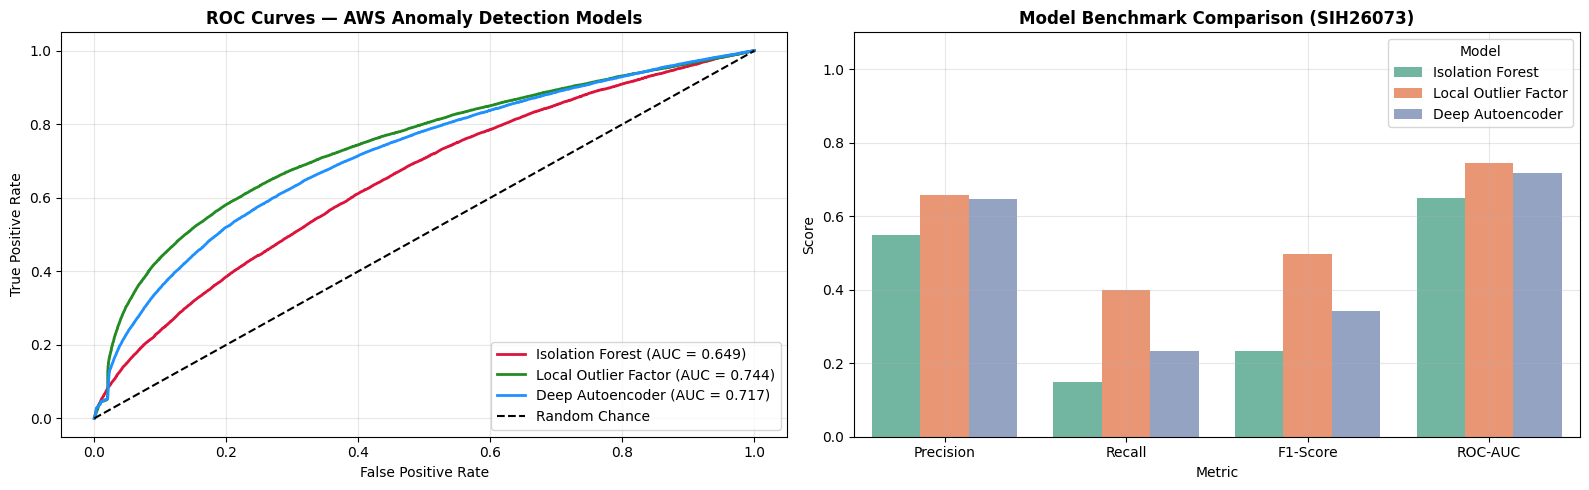


          FINAL MODEL BENCHMARK SUMMARY (SIH26073)
               Model  Precision   Recall  F1-Score  ROC-AUC
    Isolation Forest   0.548156 0.147882  0.232926 0.648798
Local Outlier Factor   0.657944 0.399992  0.497520 0.744153
    Deep Autoencoder   0.647780 0.232758  0.342464 0.716650


In [11]:
# Cell 8: Visualization & Performance Comparison
plt.figure(figsize=(16, 5))

# Plot 1: ROC Curves Comparison
plt.subplot(1, 2, 1)
fpr_if, tpr_if, _ = roc_curve(y_test, if_anomaly_scores)
fpr_lof, tpr_lof, _ = roc_curve(y_test, lof_anomaly_scores)
fpr_ae, tpr_ae, _ = roc_curve(y_test, ae_reconstruction_error)

plt.plot(fpr_if, tpr_if, label=f'Isolation Forest (AUC = {if_auc:.3f})', color='crimson', lw=2)
plt.plot(fpr_lof, tpr_lof, label=f'Local Outlier Factor (AUC = {lof_auc:.3f})', color='forestgreen', lw=2)
plt.plot(fpr_ae, tpr_ae, label=f'Deep Autoencoder (AUC = {ae_auc:.3f})', color='dodgerblue', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')

plt.title('ROC Curves — AWS Anomaly Detection Models', fontsize=12, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Plot 2: Model Performance Comparison Bar Chart
plt.subplot(1, 2, 2)
p_if, r_if, f1_if, _ = precision_recall_fscore_support(y_test, y_pred_if, average='binary')
p_lof, r_lof, f1_lof, _ = precision_recall_fscore_support(y_test, y_pred_lof, average='binary')
p_ae, r_ae, f1_ae, _ = precision_recall_fscore_support(y_test, y_pred_ae, average='binary')

metrics_df = pd.DataFrame({
    'Model': ['Isolation Forest', 'Local Outlier Factor', 'Deep Autoencoder'],
    'Precision': [p_if, p_lof, p_ae],
    'Recall': [r_if, r_lof, r_ae],
    'F1-Score': [f1_if, f1_lof, f1_ae],
    'ROC-AUC': [if_auc, lof_auc, ae_auc]
})

metrics_melted = pd.melt(metrics_df, id_vars=['Model'], var_name='Metric', value_name='Score')
sns.barplot(data=metrics_melted, x='Metric', y='Score', hue='Model', palette='Set2')
plt.title('Model Benchmark Comparison (SIH26073)', fontsize=12, fontweight='bold')
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Table
print("\n=========================================================")
print("          FINAL MODEL BENCHMARK SUMMARY (SIH26073)")
print("=========================================================")
print(metrics_df.to_string(index=False))